# Example 1: Symbolic Regressor

In [1]:
import sys
import os
from pathlib import Path
# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
from gplearn.genetic import SymbolicRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.random import check_random_state
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import graphviz
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

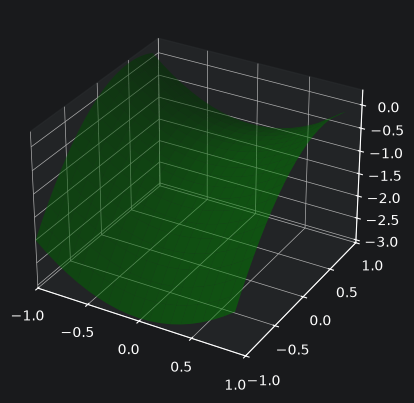

In [2]:
# Ground truth
x0 = np.arange(-1, 1, .1)
x1 = np.arange(-1, 1, .1)
x0, x1 = np.meshgrid(x0, x1)
y_truth = x0**2 - x1**2 + x1 - 1

ax = plt.figure().add_subplot(projection='3d')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks(np.arange(-1, 1.01, .5))
ax.set_yticks(np.arange(-1, 1.01, .5))
surf = ax.plot_surface(x0, x1, y_truth, rstride=1, cstride=1, color='green', alpha=0.5)
plt.show()

In [3]:
def get_benchmark_dataset(name, n_train=100, n_test=100, random_state=0):
    """
    Generates train and test datasets for standard Genetic Programming benchmarks.

    Parameters:
        name (str): Benchmark problem ('E1', 'E2', 'M1', 'M2', 'H1', 'H2')
        n_train (int): Number of training samples
        n_test (int): Number of testing samples
        random_state (int/RandomState): Seed for reproducibility

    Returns:
        X_train, y_train, X_test, y_test
    """
    rng = check_random_state(random_state)
    name = name.upper().replace("-", "").replace("_", "")

    def _generate_data(n_samples):

        # 1. Custom Domain Handling
        if name == 'NGUYEN7':
            # Sampling x from [0, 2] to prevent log(x + 1) domain errors (x <= -1)
            X = rng.uniform(0, 2, n_samples * 5).reshape(-1, 5)
        elif name == 'KEIJZER6':
            # Sampling positive values [1, 100] for harmonic number calculations
            X = rng.uniform(1, 100, n_samples * 5).reshape(-1, 5)
        else:
            # Default standard domain [-5, 5]
            X = rng.uniform(-5, 5, n_samples * 5).reshape(-1, 5)

        x1, x2, x3, x4, x5 = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

        # Define Function

        if name == 'F1':
            y = (x1 + 1) * (x2 +2) * (x3 +3) * (x4 +4) * (x5 +5)
        elif name == 'F2':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4)) + (1 / (1 + x3**-4)) + (1 / (1 + x4**-4)) + (1 / (1 + x5**-4))
        elif name == 'F3':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'F4':
            y = x1 + x2 + x3 +x4 + x5
        elif name == 'F5':
            y = x1**5 + x2**4 + x3**3 + x4**2 + x1**1

        # 2. Koza Benchmark Suite
        elif name == 'KOZA1':
            y = x1**4 + x1**3 + x1**2 + x1
        elif name == 'KOZA2':
            y = x1**5 - 2 * (x1**3) + x1
        elif name == 'KOZA3':
            y = x1**6 - 2 * (x1**4) + x1**2

        # 3. Nguyen Benchmark Suite
        elif name == 'NGUYEN1':
            y = x1**3 + x1**2 + x1
        elif name == 'NGUYEN3':
            y = x1**5 + x1**4 + x1**3 + x1**2 + x1
        elif name == 'NGUYEN5':
            y = np.sin(x1**2) * np.cos(x1) - 1
        elif name == 'NGUYEN6':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'NGUYEN7':
            y = np.log(x1 + 1) + np.log(x1**2 + 1)
        elif name == 'NGUYEN10':
            y = np.sin(x1) + np.sin(x2**2)

        # 4. Pagie Polynomial
        elif name == 'PAGIE1':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4))

        # 5. Keijzer Suite
        elif name == 'KEIJZER6':
            # Harmonic sum: sum_{i=1..x1} (1 / i)
            y = np.array([sum(1.0 / i for i in range(1, int(val) + 1)) for val in x1])

        # 6. Vladislavleva Suite
        elif name == 'VLADISLAVLEVA1':
            y = np.exp(-(x1 - 1)**2) * np.cos(x2)

        else:
            raise ValueError(f"Unknown benchmark name: '{name}'. Choose from 'E1', 'E2', 'M1', 'M2', 'H1', 'H2'.")

        return X, y

    X_train, y_train = _generate_data(n_train)
    X_test, y_test = _generate_data(n_test)

    return X_train, y_train, X_test, y_test

In [4]:
benchmarks = [
    'koza-1', 'koza-2', 'koza-3',
    'NGUYEN1', 'NGUYEN3', 'NGUYEN5',
    'NGUYEN6', 'NGUYEN7', 'NGUYEN10',
    'PAGIE1', 'KEIJZER6', 'VLADISLAVLEVA1',

    # 'NGUYEN5', 'NGUYEN6', 'NGUYEN10',
    # 'PAGIE1', 'KEIJZER6', 'VLADISLAVLEVA1'
]

plotSize = [3, 4]

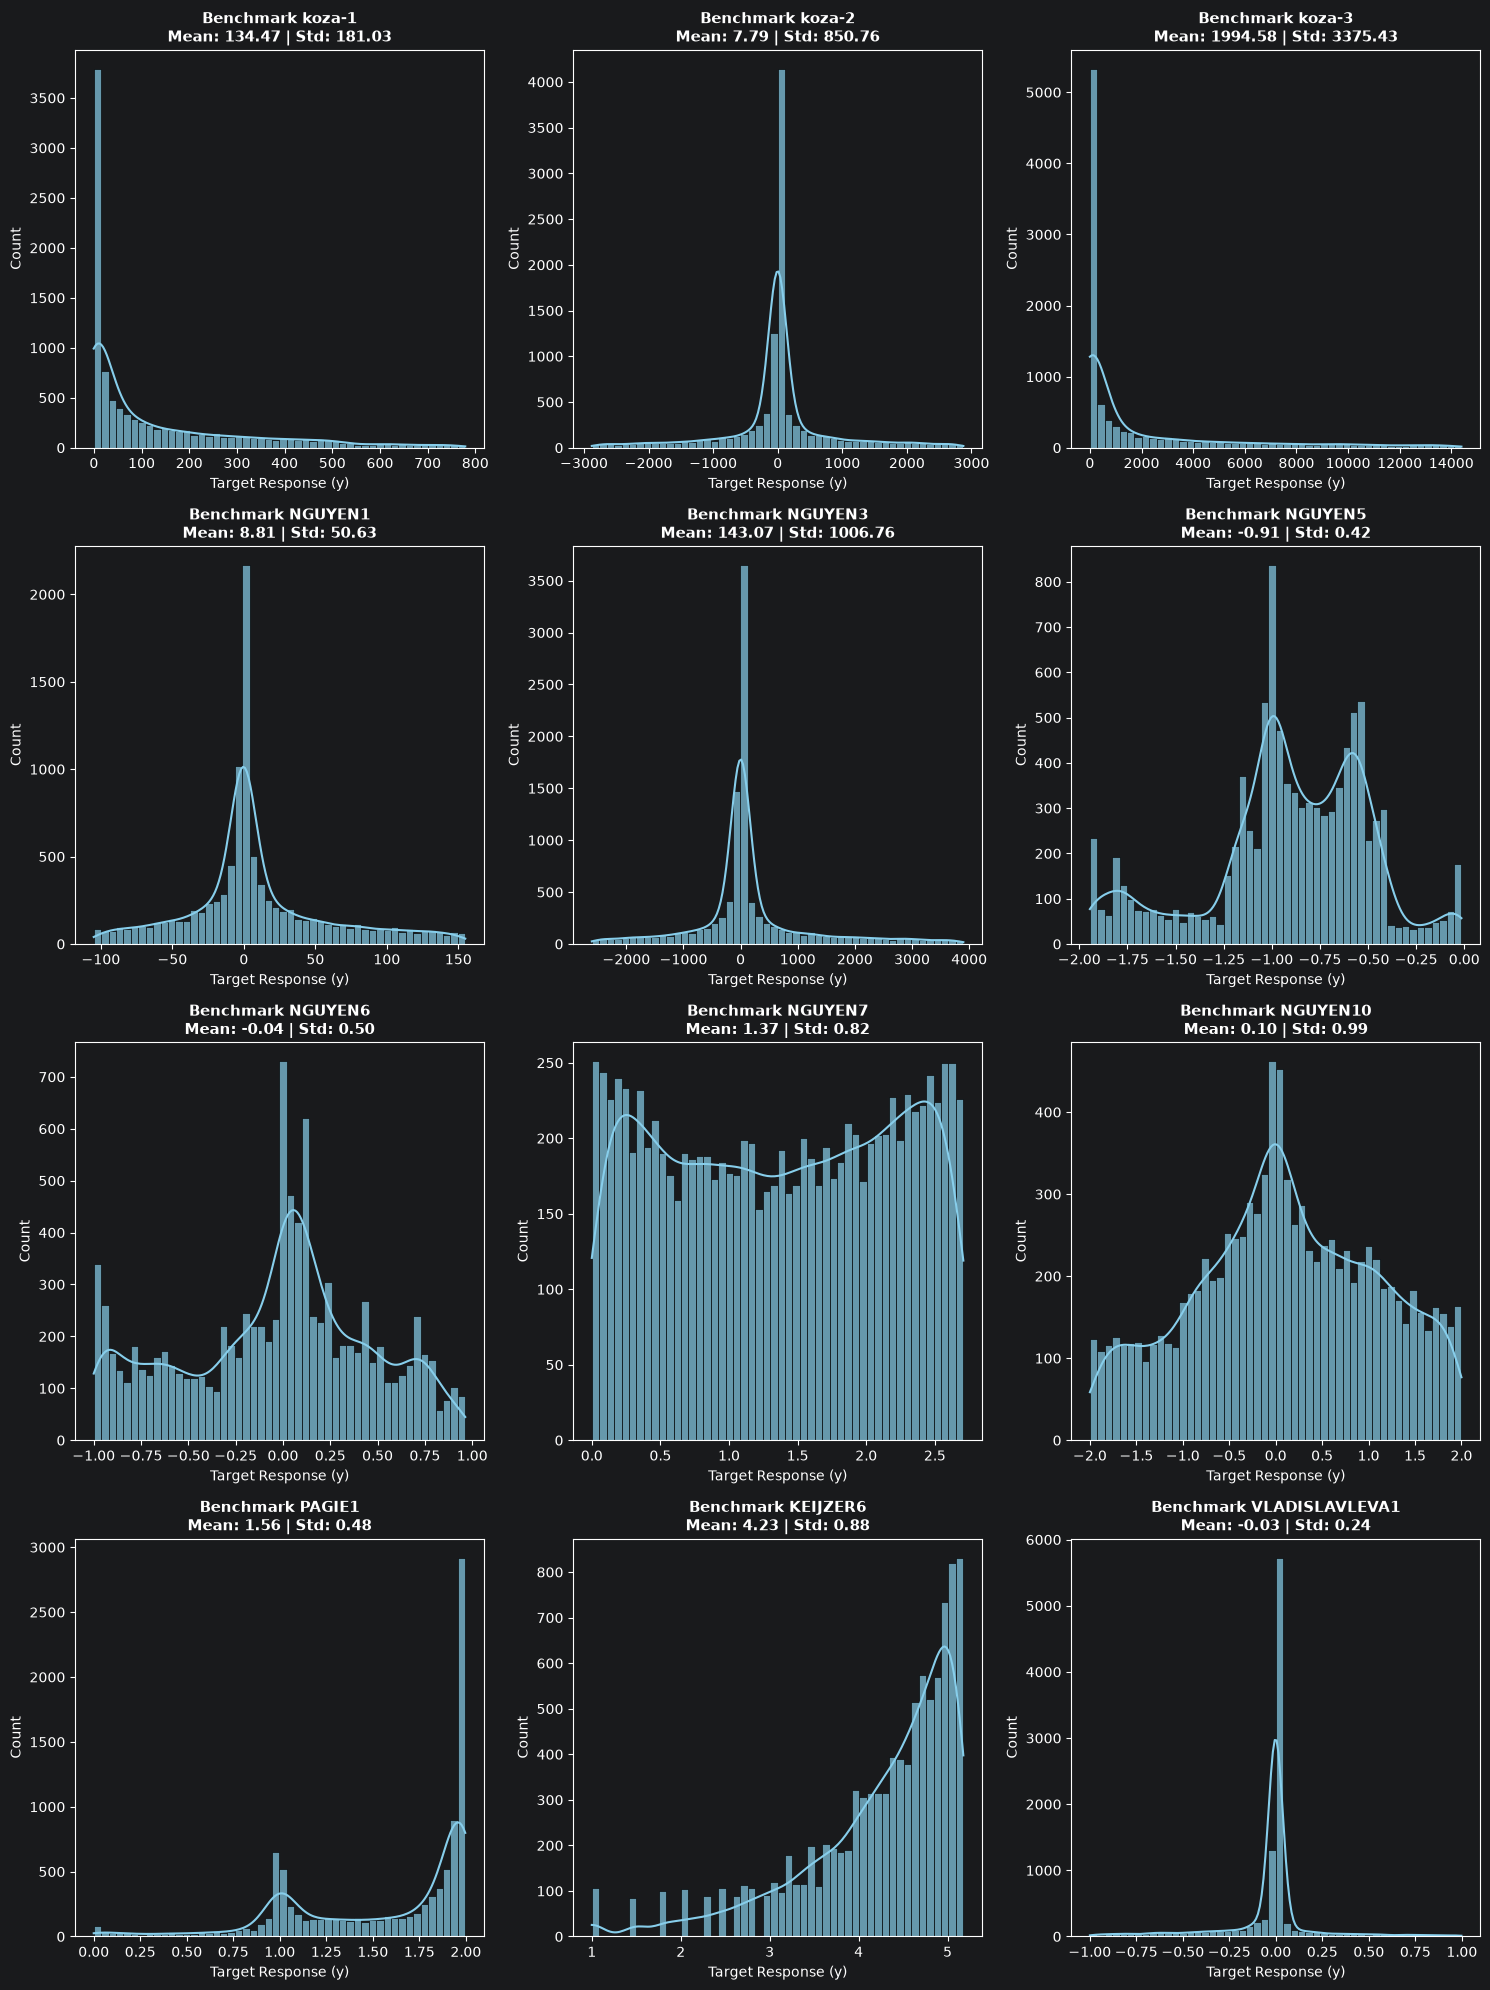

In [5]:
def plot_all_benchmarks_histogram(n_samples=10000, random_state=42, benchmarks = [], plotSize = [3, 1]):
    """
    Plots a 2x3 grid of histograms showing target distributions across all benchmark functions.
    """
    fig, axes = plt.subplots(plotSize[1], plotSize[0], figsize=(5 * plotSize[0], 5 * plotSize[1]))
    axes = axes.flatten()

    for idx, b_name in enumerate(benchmarks):
        X_tr, y_tr, _, _ = get_benchmark_dataset(b_name, n_train=n_samples, random_state=random_state)

        # Clip extreme asymptote values for H1/F16 (tan x) so outliers don't flatten the plot
        if b_name == 'H1':
            y_display = np.clip(y_tr, -100, 100)
            title_suffix = " (Clipped [-100, 100])"
        else:
            y_display = y_tr
            title_suffix = ""

        ax = axes[idx]
        sns.histplot(y_display, bins=50, kde=True, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)

        # Summary stats in title
        ax.set_title(
            f"Benchmark {b_name}{title_suffix}\nMean: {np.mean(y_tr):.2f} | Std: {np.std(y_tr):.2f}",
            fontsize=11,
            fontweight='bold'
        )
        ax.set_xlabel("Target Response (y)")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run combined plotting function
plot_all_benchmarks_histogram(benchmarks=benchmarks, plotSize = plotSize)

In [6]:
# Training Settings
est_gp = SymbolicRegressor(population_size=500,
                           generations=50, stopping_criteria=0.01,
                           tournament_size= 5,
                           p_crossover=0.7, p_subtree_mutation=0.1,
                           p_hoist_mutation=0.05, p_point_mutation=0.1,
                           max_samples=0.9, verbose=1,
                           parsimony_coefficient=0.01, random_state=0,
                           metric= 'mse')

# Calculate MAE
def print_result():
    train_r2 = r2_score(y_train, est_gp.predict(X_train))
    test_r2  = r2_score(y_test, est_gp.predict(X_test))
    print(f"Train R2 = {train_r2:.6f}")
    print(f"Test R2  = {test_r2:.6f}")

master_rng = np.random.default_rng(seed=42)
random_seeds = master_rng.integers(low=0, high=10000, size=4).tolist()

In [7]:
# X_train, y_train, X_test, y_test = get_benchmark_dataset('F3', random_state=0)
# est_gp.fit(X_train, y_train)
# print_result()

In [ ]:
results = []

for seed in random_seeds:
    print(f"\n==================== SEED {seed} ====================")

    for name in benchmarks:
        # 1. Load dataset using the current seed
        X_train, y_train, X_test, y_test = get_benchmark_dataset(name, random_state=seed)

        # 2. Instantiate GP with current random_state
        est_gp = SymbolicRegressor(
            population_size=500,
            generations=50, stopping_criteria=0.01,
            tournament_size= 5,
            p_crossover=0.7, p_subtree_mutation=0.1,
            p_hoist_mutation=0.05, p_point_mutation=0.1,
            max_samples=0.9, verbose=1,
            parsimony_coefficient=0.01, random_state=seed,
            metric= 'mse'
        )

        # 3. Train GP
        print(f"Benchmark: {name}")
        est_gp.fit(X_train, y_train)

        # 4. Predict and clean numerical issues
        y_pred = est_gp.predict(X_test)
        y_pred = np.nan_to_num(y_pred, nan=0.0, posinf=1e5, neginf=-1e5)

        # 5. Calculate Test R2
        r2 = r2_score(y_test, y_pred)

        # 6. Record findings
        results.append({
            'Seed': seed,
            'Benchmark': name,
            'R2_Score': r2,
            'Formula': str(est_gp._program)
        })

# Convert results into a DataFrame
df_results = pd.DataFrame(results)

# Display summary table with mean and standard deviation across seeds
df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
print("\n--- Summary Performance across seeds ---")
print(df_summary)

# Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
plt.figure(figsize=(15, 5))
sns.barplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    hue='Benchmark',
    palette='mako',
    errorbar='sd',       # Shows standard deviation across seeds
    capsize=0.1,         # Adds caps to error bars
    legend=False,
    edgecolor='black'
)

# Overlay individual seed points
sns.stripplot(
    data=df_results,
    x='Benchmark',
    y='R2_Score',
    color='black',
    alpha=0.6,
    jitter=0.2,
    size=5
)

plt.axhline(0, color='red', linestyle='--', label='Baseline R² = 0.0')
plt.ylim(-1.0, 1.05)
plt.title('Test R² Score Across Benchmarks (Mean ± SD over Random Seeds)', fontsize=12, fontweight='bold')
plt.ylabel('R² Score (Higher is Better)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


==================== SEED 0 ====================
Benchmark: koza-1
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    30.08      4.30642e+11        3          33551.7           159408     26.72s
   1    15.18          74182.5       15          34437.6           156707     28.44s
   2    14.50          56964.6        9          27480.1           213844     24.02s
   3    12.68            57137       11          32724.3           167412     18.16s
   4    13.30          74500.6       15          28636.3          24428.5     24.21s
   5    12.93           456852       15          31211.5          1251.84     19.27s
   6    13.08          62614.8        3          31180.3           178288     18.75s
   7    14.83      1.61986e+06       25          26705.6          46354.3     22.59s
   8   